In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Install packages
# ══════════════════════════════════════════════════════════════════════════════

!pip -q install imbalanced-learn xgboost==1.7.6 shap mord openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTENC
import xgboost as xgb
import shap
import mord

print("✅ All packages imported successfully!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 8.5 MB/s eta 0:00:00
✅ All packages imported successfully!


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Load data from Google Drive
# ══════════════════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = "/content/drive/MyDrive/Database COMPLETO corretto 23_01_23.csv"

df = pd.read_csv(CSV_PATH)

print(f"✅ Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded dataset: 258 rows × 91 columns
Missing values: 0


,Sex,Age,School failure,Whatsapp,Facebook,Instagram,Twitter,Snapchat,TikTok,Other social media,...,STAI-Y2_12,STAI-Y2_13,STAI-T2_14,STAI-Y2_15,STAI-2_16,STAI-Y2_17,STAI-Y2_18,STAI-Y2_19,STAI-Y2_20,TOT_STAI-Y2
0,2,18,0,1,0,1,0,0,1,0,...,1,4,2,1,1,3,2,1,3,37
1,2,19,1,1,1,1,0,0,0,0,...,3,2,4,3,2,1,1,3,4,52
2,1,18,0,1,0,1,0,0,0,0,...,2,3,2,1,1,1,1,3,1,34
3,1,17,1,1,1,1,0,0,1,0,...,1,4,1,1,1,4,1,1,1,30
4,1,17,0,1,0,1,0,0,0,0,...,1,2,2,2,2,2,2,2,3,40


DATASET OVERVIEW

Shape: (258, 91)

Demographics:
  Sex       → 1=Male(109), 2=Female(149)
  Age       → range 14–22, mean=17.4
  School failure → Yes: 91, No: 167

Psychometric Scale Summary:
       TOT_BSMAS  TOT_RSES  TOT_CSIQ-A  TOT_STAI-Y1  TOT_STAI-Y2
count     258.00    258.00      258.00       258.00       258.00
mean       13.07     16.59       21.35        42.67        45.88
std         4.49      5.01        5.15         9.93        10.21
min         6.00      3.00       10.00        25.00        23.00
25%        10.00     13.00       17.00        35.00        38.00
50%        13.00     17.00       21.00        41.00        46.00
75%        16.00     20.00       25.00        49.00        53.00
max        27.00     27.00       37.00        74.00        71.00

Cutoff Distributions:
  BSMAS_CUTOFF: {0: 229, 1: 29}
  RSES_CUTOFF: {0: 105, 1: 153}
  CSIQ-A CUFOTT: {0: 134, 1: 124}


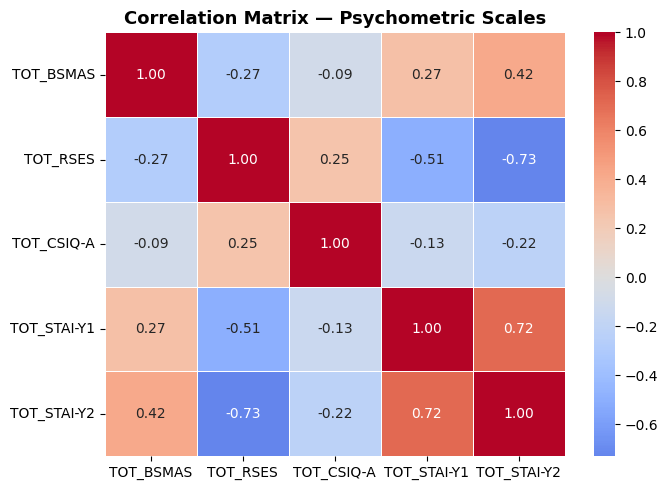

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Exploration (EDA)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nShape: {df.shape}")
print(f"\nDemographics:")
print(f"  Sex       → 1=Male({(df['Sex']==1).sum()}), 2=Female({(df['Sex']==2).sum()})")
print(f"  Age       → range {df['Age'].min()}–{df['Age'].max()}, mean={df['Age'].mean():.1f}")
print(f"  School failure → Yes: {(df['School failure']==1).sum()}, No: {(df['School failure']==0).sum()}")

psych_cols = ['TOT_BSMAS', 'TOT_RSES', 'TOT_CSIQ-A', 'TOT_STAI-Y1', 'TOT_STAI-Y2']
print(f"\nPsychometric Scale Summary:")
print(df[psych_cols].describe().round(2))

print(f"\nCutoff Distributions:")
for col in ['BSMAS_CUTOFF', 'RSES_CUTOFF', 'CSIQ-A CUFOTT']:
    counts = df[col].value_counts().sort_index()
    print(f"  {col}: {counts.to_dict()}")

# Correlation heatmap of psych scales
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[psych_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Psychometric Scales", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  k=2: inertia=848.1, silhouette=0.2935
  k=3: inertia=717.8, silhouette=0.2174
  k=4: inertia=621.0, silhouette=0.2172
  k=5: inertia=550.2, silhouette=0.2273
  k=6: inertia=505.7, silhouette=0.2064
  k=7: inertia=469.7, silhouette=0.2042


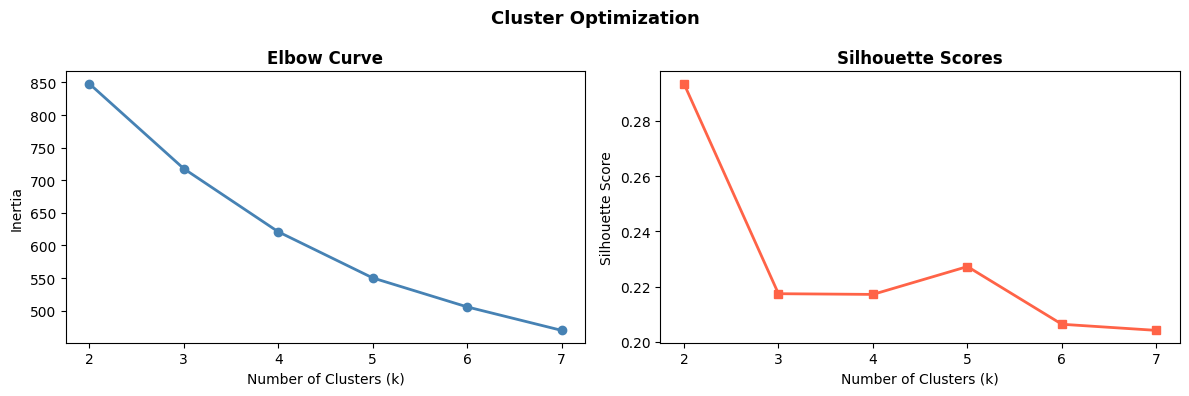

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Phase 1: Optimal Cluster Discovery
# ══════════════════════════════════════════════════════════════════════════════

psych_cols = ['TOT_BSMAS', 'TOT_RSES', 'TOT_CSIQ-A', 'TOT_STAI-Y1', 'TOT_STAI-Y2']
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df[psych_cols])

# Elbow + Silhouette
inertias, silhouettes = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))
    print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_score(X_clust, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title("Elbow Curve", fontweight='bold')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker='s', color='tomato', linewidth=2)
axes[1].set_title("Silhouette Scores", fontweight='bold')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.suptitle("Cluster Optimization", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

CLUSTER PROFILES — PSYCHOLOGICAL CHARACTERISTICS
               TOT_BSMAS  TOT_RSES  TOT_CSIQ-A  TOT_STAI-Y1  TOT_STAI-Y2
Low Risk           11.02     20.47       23.82        35.04        36.70
Moderate Risk      13.23     15.79       20.09        43.85        47.65
High Risk          17.28      9.91       19.16        56.84        61.95

Cluster sizes:
  Low Risk: 98 students (38.0%)
  Moderate Risk: 117 students (45.3%)
  High Risk: 43 students (16.7%)

SM Addiction cutoff (BSMAS) per cluster:
RISK_PROFILE
Low Risk         0.041
Moderate Risk    0.094
High Risk        0.326
Name: BSMAS_CUTOFF, dtype: float64


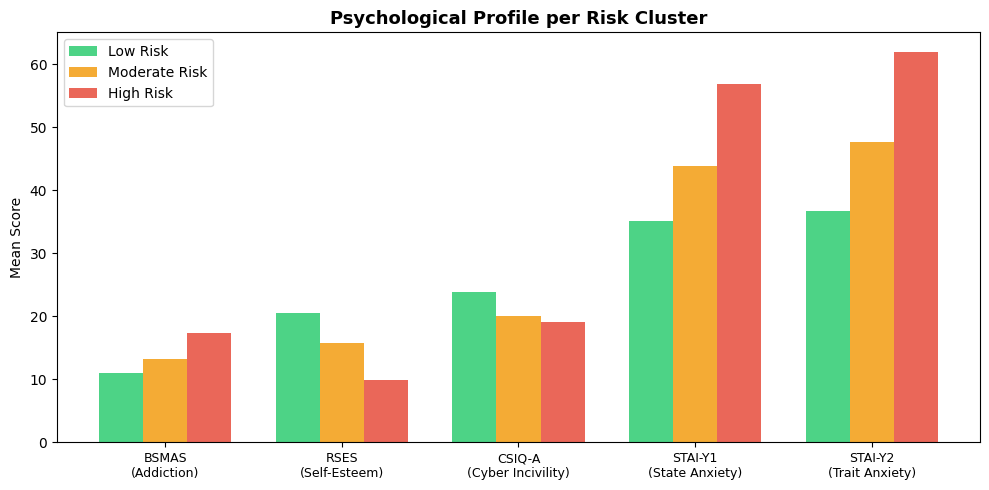

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Phase 1: Final Clustering (k=3) + Profile Labeling
# ══════════════════════════════════════════════════════════════════════════════

OPTIMAL_K = 3
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
df['cluster_raw'] = km_final.fit_predict(X_clust)

# Auto-label clusters by BSMAS mean (Low=0, Moderate=1, High=2)
cluster_means = df.groupby('cluster_raw')['TOT_BSMAS'].mean().sort_values()
label_map = {old: new for new, old in enumerate(cluster_means.index)}
df['RISK_PROFILE'] = df['cluster_raw'].map(label_map)

PROFILE_NAMES = {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
PROFILE_COLORS = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

print("=" * 60)
print("CLUSTER PROFILES — PSYCHOLOGICAL CHARACTERISTICS")
print("=" * 60)
profile_summary = df.groupby('RISK_PROFILE')[psych_cols].mean().round(2)
profile_summary.index = [PROFILE_NAMES[i] for i in profile_summary.index]
print(profile_summary.to_string())

print("\nCluster sizes:")
for k, v in df['RISK_PROFILE'].value_counts().sort_index().items():
    print(f"  {PROFILE_NAMES[k]}: {v} students ({v/len(df)*100:.1f}%)")

print("\nSM Addiction cutoff (BSMAS) per cluster:")
print(df.groupby('RISK_PROFILE')['BSMAS_CUTOFF'].mean().round(3).rename(PROFILE_NAMES))

# Radar / bar chart of cluster profiles
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(psych_cols))
width = 0.25
for i, (pid, pname) in enumerate(PROFILE_NAMES.items()):
    vals = df[df['RISK_PROFILE'] == pid][psych_cols].mean().values
    ax.bar(x + i * width, vals, width, label=pname, color=PROFILE_COLORS[pid], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(['BSMAS\n(Addiction)', 'RSES\n(Self-Esteem)', 'CSIQ-A\n(Cyber Incivility)',
                    'STAI-Y1\n(State Anxiety)', 'STAI-Y2\n(Trait Anxiety)'], fontsize=9)
ax.set_ylabel("Mean Score")
ax.set_title("Psychological Profile per Risk Cluster", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 (FIXED) — Define Features & Target, Train-Test Split
# ══════════════════════════════════════════════════════════════════════════════
# KEY FIX: Include individual psychometric items as features.
# The cluster is built from TOTALS (e.g. TOT_BSMAS) but we use the
# raw ITEMS as features — this is clinically valid because a counselor
# collects item-level responses, not pre-computed totals.
# We NEVER include TOT_BSMAS / TOT_RSES etc. (that would be leakage).

SM_COLS = [
    'Sex', 'Age', 'School failure',
    'Whatsapp', 'Facebook', 'Instagram', 'Twitter', 'Snapchat', 'TikTok',
    'Other social media', 'Time spent on social media', 'Daily use of social media',
    'Which device', "Time's flow",
    'Perceived anxiety during SM use ', 'Perceived loneliness',
    'Social media checking', 'Video-game and online play',
    'Time spent palying videogames'
]

BSMAS_ITEMS = ['BSMAS1', 'BSMA2', 'BSMAS3', 'BSMAS4', 'BSMAS5', 'BSMAS6']
RSES_ITEMS  = ['RSES1','RSES2','RSES3','RSES4','RSES5','RSES6',
               'RSES7','RSES8','RSES9','RSES10']
CSIQ_ITEMS  = ['CSIQ-A1','CSIQ-A2','CSIQ-A3','CSIQ-A4',
               'CSIQ-A5','CSIQ-A6','CSIQ-A7','CSIQ-A8']

# All STAI-Y1 and STAI-Y2 individual items (handle the typo column names in dataset)
STAI_ITEMS = [c for c in df.columns if re.match(r'STAI-(Y1|Y2|T2|2)[-_]\d+', c)]

ALL_ITEM_COLS = BSMAS_ITEMS + RSES_ITEMS + CSIQ_ITEMS + STAI_ITEMS

# Final feature set: SM behavior + demographics + all individual scale items
FEATURE_COLS = SM_COLS + ALL_ITEM_COLS
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

# Sanity check — make sure NO total scores leaked in
FORBIDDEN = ['TOT_BSMAS','TOT_RSES','TOT_CSIQ-A','TOT_STAI-Y1','TOT_STAI-Y2',
             'BSMAS_CUTOFF','RSES_CUTOFF','CSIQ-A CUFOTT',
             'cluster_raw','RISK_PROFILE']
FEATURE_COLS = [c for c in FEATURE_COLS if c not in FORBIDDEN]

print(f"✅ Total features: {len(FEATURE_COLS)}")
print(f"   SM behavior cols : {len([c for c in SM_COLS if c in FEATURE_COLS])}")
print(f"   BSMAS items      : {len([c for c in BSMAS_ITEMS if c in FEATURE_COLS])}")
print(f"   RSES items       : {len([c for c in RSES_ITEMS if c in FEATURE_COLS])}")
print(f"   CSIQ-A items     : {len([c for c in CSIQ_ITEMS if c in FEATURE_COLS])}")
print(f"   STAI items       : {len([c for c in STAI_ITEMS if c in FEATURE_COLS])}")

X = df[FEATURE_COLS].copy()
y = df['RISK_PROFILE'].copy()

print(f"\nClass distribution:")
for k, v in y.value_counts().sort_index().items():
    print(f"  Class {k} ({PROFILE_NAMES[k]}): {v}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"\nTrain: {X_train.shape},  Test: {X_test.shape}")

✅ Total features: 83
   SM behavior cols : 19
   BSMAS items      : 6
   RSES items       : 10
   CSIQ-A items     : 8
   STAI items       : 40

Class distribution:
  Class 0 (Low Risk): 98
  Class 1 (Moderate Risk): 117
  Class 2 (High Risk): 43

Train: (206, 83),  Test: (52, 83)


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 (FIXED) — IRT-Inspired Latent Trait θ from BSMAS items
# ══════════════════════════════════════════════════════════════════════════════
# θ is computed from BSMAS items and then APPENDED as an extra feature.
# Since BSMAS items are already in X_train, θ adds a PCA-compressed
# summary of addiction severity on top — this is the psychometric innovation.

print(f"Computing θ from BSMAS items: {BSMAS_ITEMS}")

# Use the BSMAS item columns that are already in X_train (no extra df.loc needed)
bsmas_in_features = [c for c in BSMAS_ITEMS if c in X_train.columns]

scaler_theta = StandardScaler()
pca_theta    = PCA(n_components=1, random_state=42)

bsmas_train_scaled = scaler_theta.fit_transform(X_train[bsmas_in_features])
theta_train        = pca_theta.fit_transform(bsmas_train_scaled).ravel()

bsmas_test_scaled  = scaler_theta.transform(X_test[bsmas_in_features])
theta_test         = pca_theta.transform(bsmas_test_scaled).ravel()

X_train = X_train.copy()
X_test  = X_test.copy()
X_train['theta_latent'] = theta_train
X_test['theta_latent']  = theta_test

explained_var = pca_theta.explained_variance_ratio_[0] * 100
print(f"✅ θ added — explains {explained_var:.1f}% of BSMAS item variance")
print(f"   θ train: mean={theta_train.mean():.3f}, std={theta_train.std():.3f}")
print(f"   Feature set now: {X_train.shape[1]} total features")

Computing θ from BSMAS items: ['BSMAS1', 'BSMA2', 'BSMAS3', 'BSMAS4', 'BSMAS5', 'BSMAS6']
✅ θ added — explains 41.7% of BSMAS item variance
   θ train: mean=0.000, std=1.582
   Feature set now: 84 total features


Categorical columns (12): ['Sex', 'School failure', 'Whatsapp', 'Facebook', 'Instagram', 'Twitter', 'Snapchat', 'TikTok', 'Other social media', 'Daily use of social media', 'Which device', 'Video-game and online play']
Categorical indices: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 17]

Before balancing: {0: 78, 1: 94, 2: 34}
After balancing : {0: 94, 1: 94, 2: 94}
✅ Training set: 206 → 282 samples


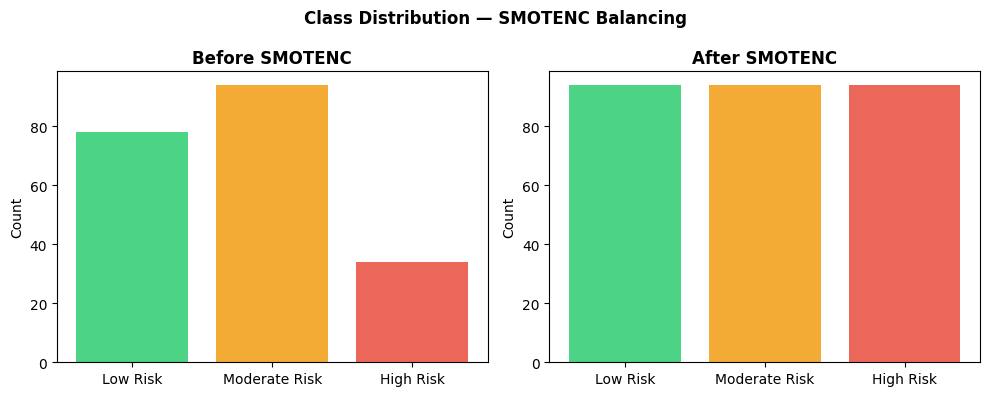

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 (FIXED) — SMOTENC Balancing
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTANT: With more features now, we need to correctly identify
# which are categorical. Psychometric Likert items (1-5) are treated
# as continuous by SMOTENC (safer for interpolation).

CAT_COLS = [
    'Sex', 'School failure',
    'Whatsapp', 'Facebook', 'Instagram', 'Twitter', 'Snapchat', 'TikTok',
    'Other social media', 'Daily use of social media',
    'Which device', 'Video-game and online play'
]
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]
cat_idx  = [X_train.columns.get_loc(c) for c in CAT_COLS]

print(f"Categorical columns ({len(CAT_COLS)}): {CAT_COLS}")
print(f"Categorical indices: {cat_idx}")
print(f"\nBefore balancing: {y_train.value_counts().sort_index().to_dict()}")

sm = SMOTENC(categorical_features=cat_idx, random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print(f"After balancing : {pd.Series(y_train_bal).value_counts().sort_index().to_dict()}")
print(f"✅ Training set: {X_train.shape[0]} → {X_train_bal.shape[0]} samples")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes,
    [y_train.value_counts().sort_index(),
     pd.Series(y_train_bal).value_counts().sort_index()],
    ['Before SMOTENC', 'After SMOTENC']):
    colors = [PROFILE_COLORS[i] for i in counts.index]
    ax.bar([PROFILE_NAMES[i] for i in counts.index], counts.values,
           color=colors, alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Count")
plt.suptitle("Class Distribution — SMOTENC Balancing", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Evaluation Helper Function
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_model(clf, X_te, y_te, name="Model", proba_method="predict_proba"):
    """Unified evaluation: report + confusion matrix + ROC-AUC."""
    X_input = X_te.values if isinstance(X_te, pd.DataFrame) else X_te
    y_pred = clf.predict(X_input)

    print(f"\n{'='*60}")
    print(f"  {name} — Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred, digits=4,
                                 target_names=[PROFILE_NAMES[i] for i in sorted(np.unique(y_te))]))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=[PROFILE_NAMES[i] for i in sorted(np.unique(y_te))],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ROC-AUC
    if hasattr(clf, proba_method):
        y_score = getattr(clf, proba_method)(X_input)
        classes = sorted(np.unique(y_te))
        y_bin = label_binarize(y_te, classes=classes)
        try:
            macro_auc = roc_auc_score(y_bin, y_score, average="macro", multi_class='ovr')
            micro_auc = roc_auc_score(y_bin, y_score, average="micro", multi_class='ovr')
            print(f"  Macro AUC : {macro_auc:.4f}")
            print(f"  Micro AUC : {micro_auc:.4f}")
            RocCurveDisplay.from_predictions(y_bin.ravel(), np.asarray(y_score).ravel())
            plt.title(f"{name} — ROC Curve (OvR)")
            plt.show()
        except Exception as e:
            print(f"  AUC skipped: {e}")

    return y_pred

✅ Monotone constraints applied to 57 features:
   BSMAS1: ↑ increasing (+1)
   BSMA2: ↑ increasing (+1)
   BSMAS3: ↑ increasing (+1)
   BSMAS4: ↑ increasing (+1)
   BSMAS5: ↑ increasing (+1)
   BSMAS6: ↑ increasing (+1)
   RSES1: ↓ decreasing (-1)
   RSES2: ↓ decreasing (-1)
   RSES3: ↓ decreasing (-1)
   RSES4: ↓ decreasing (-1)
   RSES5: ↓ decreasing (-1)
   RSES6: ↓ decreasing (-1)
   RSES7: ↓ decreasing (-1)
   RSES8: ↓ decreasing (-1)
   RSES9: ↓ decreasing (-1)
   RSES10: ↓ decreasing (-1)
   STAI-Y1_1: ↑ increasing (+1)
   STAI-Y1_2: ↑ increasing (+1)
   STAI-Y1_3: ↑ increasing (+1)
   STAI-Y1-4: ↑ increasing (+1)
   STAI-Y1_5: ↑ increasing (+1)
   STAI-Y1_6: ↑ increasing (+1)
   STAI-Y1_7: ↑ increasing (+1)
   STAI-Y1_8: ↑ increasing (+1)
   STAI-Y1_9: ↑ increasing (+1)
   STAI-Y1_10: ↑ increasing (+1)
   STAI-Y1_11: ↑ increasing (+1)
   STAI-Y1_12: ↑ increasing (+1)
   STAI-Y1_13: ↑ increasing (+1)
   STAI-Y1_14: ↑ increasing (+1)
   STAI-Y1_15: ↑ increasing (+1)
   STAI-Y1_16

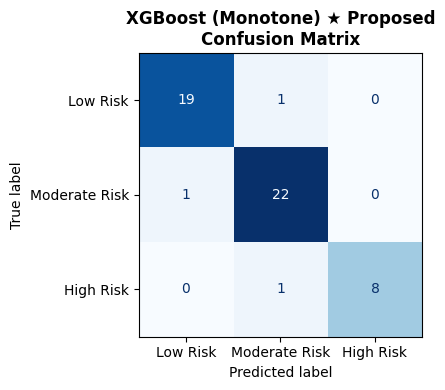

  Macro AUC : 0.9985
  Micro AUC : 0.9983


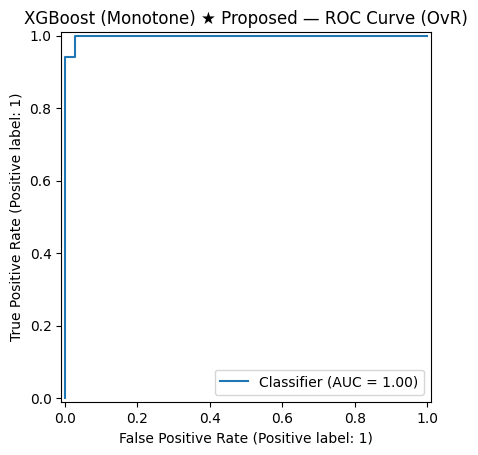

array([0, 2, 0, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 0, 0,
       2, 2, 1, 2, 0, 0, 0, 1])

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 (FIXED) — XGBoost with Monotonic Constraints (PROPOSED MODEL)
# ══════════════════════════════════════════════════════════════════════════════
# FIXED monotone logic:
#   BSMAS items  → +1  (higher addiction symptom = higher risk, enforced)
#   STAI items   → +1  (higher anxiety = higher risk, enforced)
#   RSES items   → -1  (higher self-esteem = lower risk, enforced)
#   CSIQ-A items →  0  (cyber incivility — no clear monotone direction)
#   theta_latent → +1  (higher latent addiction intensity = higher risk)
#   SM behavior  →  0  (flexible, non-monotone)

mono = []
for c in X_train_bal.columns:
    if re.match(r'BSMAS\d+$', c) or c == 'BSMA2':
        mono.append(1)   # addiction items: higher = more risk
    elif re.match(r'STAI-(Y1|Y2|T2|2)[-_]\d+', c):
        mono.append(1)   # anxiety items: higher = more risk
    elif re.match(r'RSES\d+$', c):
        mono.append(-1)  # self-esteem items: higher = LESS risk
    elif c == 'theta_latent':
        mono.append(1)   # latent trait: higher = more risk
    else:
        mono.append(0)   # SM behavior, demographics: unconstrained

# Print summary
constrained = [(c, v) for c, v in zip(X_train_bal.columns, mono) if v != 0]
print(f"✅ Monotone constraints applied to {len(constrained)} features:")
for c, v in constrained:
    direction = '↑ increasing (+1)' if v == 1 else '↓ decreasing (-1)'
    print(f"   {c}: {direction}")
print(f"   ({len(mono) - len(constrained)} features unconstrained)")

print("\nTraining Monotonic XGBoost (Proposed Model)...")
xgb_monotone = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=400,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    monotone_constraints="(" + ",".join(map(str, mono)) + ")",
    random_state=42,
    tree_method="hist",
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_monotone.fit(X_train_bal, y_train_bal)
evaluate_model(xgb_monotone, X_test, y_test, name="XGBoost (Monotone) ★ Proposed")


  MODEL PERFORMANCE — XGBoost Monotone
               Model  Accuracy  Macro_F1  Weighted_F1  F1 — Low Risk  F1 — Mod Risk  F1 — High Risk
XGBoost (Monotone) ★    0.9423    0.9424       0.9424           0.95         0.9362          0.9412


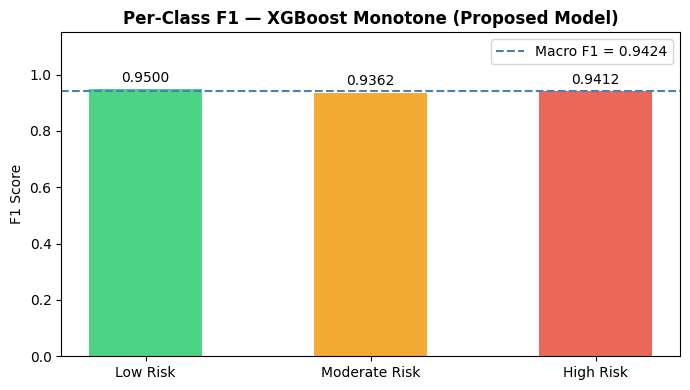

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Performance Summary Table
# ══════════════════════════════════════════════════════════════════════════════

def get_metrics(clf, X_te, y_te, name):
    X_input = X_te.values if isinstance(X_te, pd.DataFrame) else X_te
    y_pred  = clf.predict(X_input)
    rep     = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    return {
        "Model"            : name,
        "Accuracy"         : round(rep['accuracy'], 4),
        "Macro_F1"         : round(rep['macro avg']['f1-score'], 4),
        "Weighted_F1"      : round(rep['weighted avg']['f1-score'], 4),
        "F1 — Low Risk"    : round(rep.get('0', rep.get(0, {})).get('f1-score', 0), 4),
        "F1 — Mod Risk"    : round(rep.get('1', rep.get(1, {})).get('f1-score', 0), 4),
        "F1 — High Risk"   : round(rep.get('2', rep.get(2, {})).get('f1-score', 0), 4),
    }

result = get_metrics(xgb_monotone, X_test, y_test, "XGBoost (Monotone) ★")
result_df = pd.DataFrame([result])

print("\n" + "="*60)
print("  MODEL PERFORMANCE — XGBoost Monotone")
print("="*60)
print(result_df.to_string(index=False))

# Visual bar chart of per-class F1
fig, ax = plt.subplots(figsize=(7, 4))
classes  = ['Low Risk', 'Moderate Risk', 'High Risk']
f1_vals  = [result['F1 — Low Risk'], result['F1 — Mod Risk'], result['F1 — High Risk']]
colors   = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(classes, f1_vals, color=colors, alpha=0.85, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.axhline(y=result['Macro_F1'], color='steelblue', linestyle='--',
           linewidth=1.5, label=f"Macro F1 = {result['Macro_F1']:.4f}")
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 — XGBoost Monotone (Proposed Model)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — 5-Fold Cross-Validation (Robustness Check)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  5-FOLD CROSS-VALIDATION — XGBoost Monotone")
print("="*60)

mono_str = "(" + ",".join(map(str, mono)) + ")"
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_bal, y_train_bal), 1):
    Xtr = X_train_bal.iloc[tr_idx]
    Xva = X_train_bal.iloc[va_idx]
    ytr = y_train_bal.iloc[tr_idx] if hasattr(y_train_bal, 'iloc') else y_train_bal[tr_idx]
    yva = y_train_bal.iloc[va_idx] if hasattr(y_train_bal, 'iloc') else y_train_bal[va_idx]

    clf_cv = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3,
        max_depth=4, learning_rate=0.05, n_estimators=400,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        monotone_constraints=mono_str,
        random_state=42, tree_method="hist",
        use_label_encoder=False, eval_metric='mlogloss'
    )
    clf_cv.fit(Xtr, ytr)
    pred  = clf_cv.predict(Xva)
    rep   = classification_report(yva, pred, output_dict=True, zero_division=0)
    score = rep['macro avg']['f1-score']
    cv_scores.append(score)
    print(f"  Fold {fold}: Macro F1 = {score:.4f}")

print(f"\n  ✅ Mean Macro F1 : {np.mean(cv_scores):.4f}")
print(f"     Std Dev       : {np.std(cv_scores):.4f}")
print(f"     95% CI        : [{np.mean(cv_scores)-1.96*np.std(cv_scores):.4f}, "
      f"{np.mean(cv_scores)+1.96*np.std(cv_scores):.4f}]")


  5-FOLD CROSS-VALIDATION — XGBoost Monotone
  Fold 1: Macro F1 = 0.8936
  Fold 2: Macro F1 = 0.8720
  Fold 3: Macro F1 = 0.9464
  Fold 4: Macro F1 = 0.9820
  Fold 5: Macro F1 = 0.9458

  ✅ Mean Macro F1 : 0.9279
     Std Dev       : 0.0397
     95% CI        : [0.8501, 1.0058]


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 (FIXED) — Fairness Analysis (by Sex, Age Group, School Failure)
# ══════════════════════════════════════════════════════════════════════════════

def fairness_slice(model, X_te, y_te, col, vals, val_names, drop_cols=None):
    print(f"\n  Slicing by: {col}")
    for v, vname in zip(vals, val_names):
        idx = X_te[col] == v
        Xs  = X_te[idx]
        ys  = y_te[idx]

        # Drop any extra columns not seen during training
        if drop_cols:
            Xs = Xs.drop(columns=[c for c in drop_cols if c in Xs.columns])

        if len(ys) < 5:
            print(f"    {vname}: too few samples (n={len(ys)}), skipped")
            continue

        y_pred = model.predict(Xs)
        rep    = classification_report(ys, y_pred, output_dict=True, zero_division=0)
        f1     = rep['macro avg']['f1-score']
        acc    = rep['accuracy']
        print(f"    {vname:15s} (n={len(ys):3d}):  Macro F1 = {f1:.4f}  |  Accuracy = {acc:.4f}")

print("=" * 60)
print("  FAIRNESS ANALYSIS — XGBoost Monotone")
print("=" * 60)

# Sex
fairness_slice(xgb_monotone, X_test, y_test,
               'Sex', [1, 2], ['Male', 'Female'])

# Age group — add column for slicing, drop before predicting
X_test_age = X_test.copy()
X_test_age['age_group'] = pd.cut(
    X_test_age['Age'], bins=[0, 16, 18, 99], labels=[1, 2, 3]
)
fairness_slice(xgb_monotone, X_test_age, y_test,
               'age_group', [1, 2, 3], ['Age ≤16', 'Age 17-18', 'Age ≥19'],
               drop_cols=['age_group'])  # ← drop before model.predict()

# School failure
fairness_slice(xgb_monotone, X_test, y_test,
               'School failure', [0, 1], ['No Failure', 'Has Failure'])

  FAIRNESS ANALYSIS — XGBoost Monotone

  Slicing by: Sex
    Male            (n= 22):  Macro F1 = 0.6076  |  Accuracy = 0.9091
    Female          (n= 30):  Macro F1 = 0.9596  |  Accuracy = 0.9667

  Slicing by: age_group
    Age ≤16         (n= 20):  Macro F1 = 1.0000  |  Accuracy = 1.0000
    Age 17-18       (n= 22):  Macro F1 = 0.9327  |  Accuracy = 0.9091
    Age ≥19         (n= 10):  Macro F1 = 0.8963  |  Accuracy = 0.9000

  Slicing by: School failure
    No Failure      (n= 35):  Macro F1 = 0.9177  |  Accuracy = 0.9143
    Has Failure     (n= 17):  Macro F1 = 1.0000  |  Accuracy = 1.0000


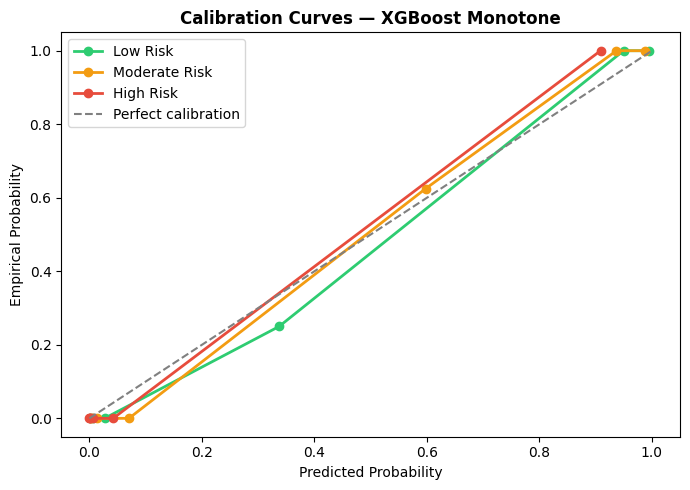

In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — Calibration Curves
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.calibration import calibration_curve

probs  = xgb_monotone.predict_proba(X_test)
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 5))
for cls in range(3):
    y_true_cls = (y_test == cls).astype(int)
    y_prob_cls = probs[:, cls]
    frac_pos, mean_pred = calibration_curve(
        y_true_cls, y_prob_cls, n_bins=6, strategy='quantile'
    )
    ax.plot(mean_pred, frac_pos, marker='o', color=colors[cls],
            label=PROFILE_NAMES[cls], linewidth=2)

ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Empirical Probability")
ax.set_title("Calibration Curves — XGBoost Monotone", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

  SHAP GLOBAL ANALYSIS — HIGH RISK CLASS

📊 Beeswarm Plot — feature impact & direction


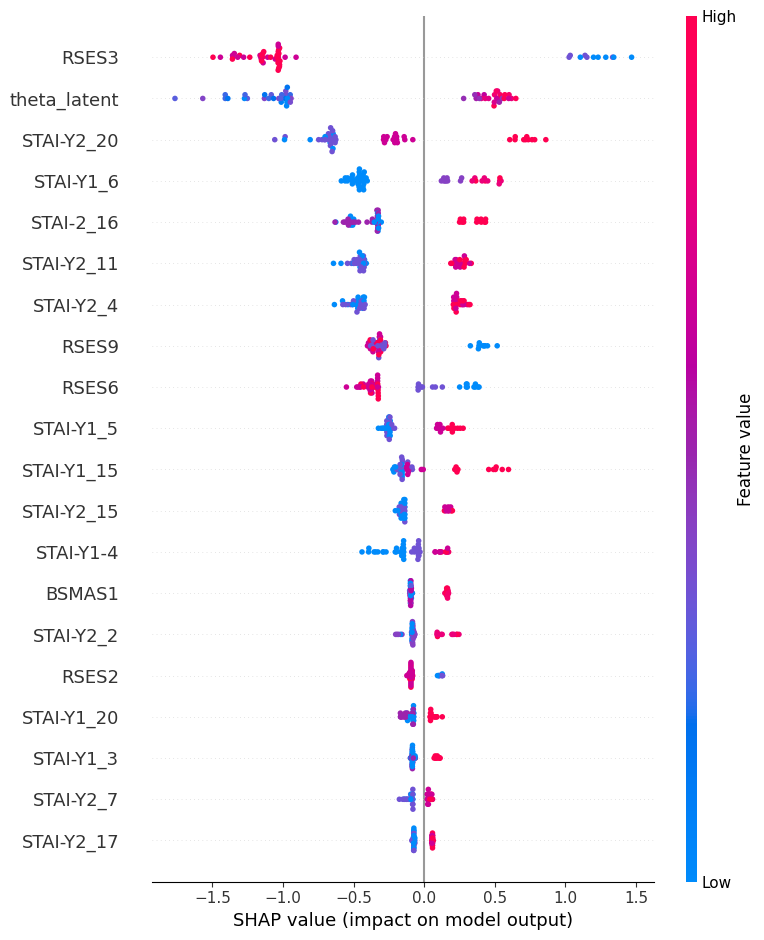


📊 Feature Importance Bar Plot


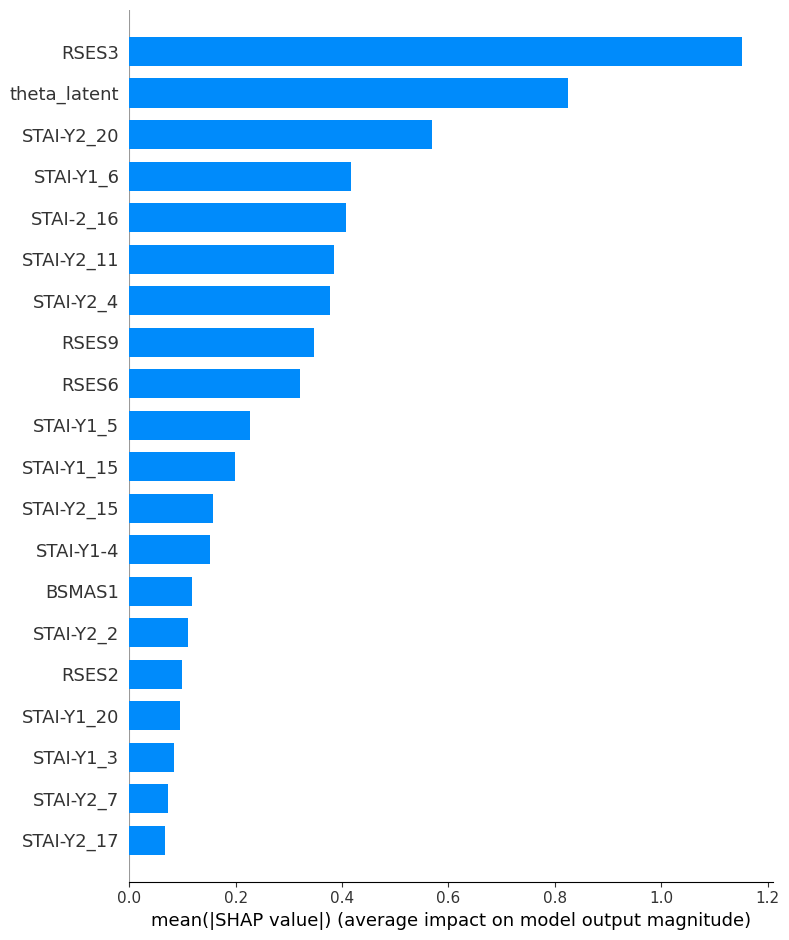


🔍 Top 3 influential features: ['RSES3', 'theta_latent', 'STAI-Y2_20']

📊 Dependence Plot → RSES3


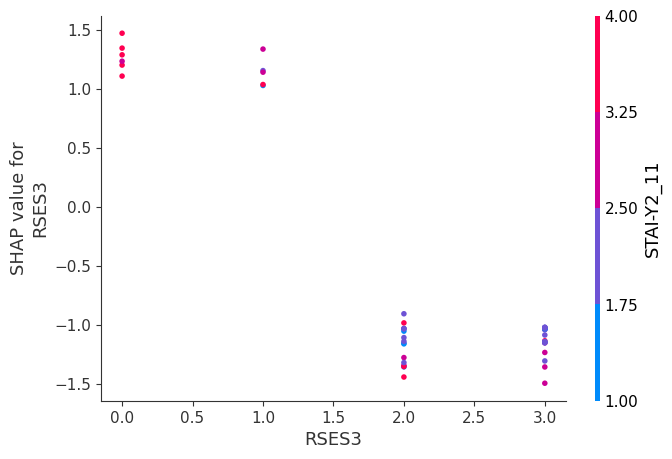


📊 Dependence Plot → theta_latent


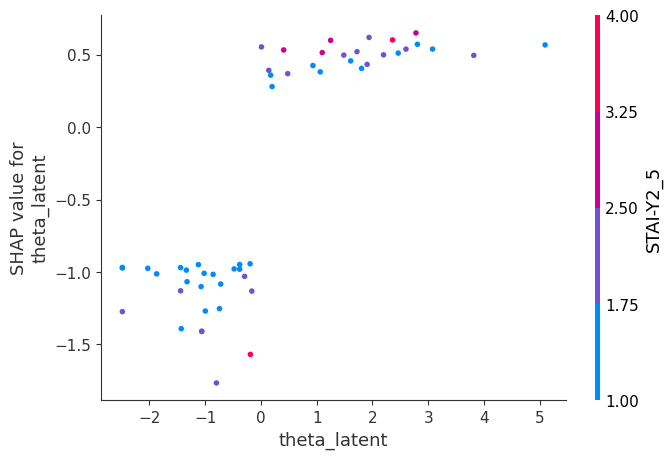


📊 Dependence Plot → STAI-Y2_20


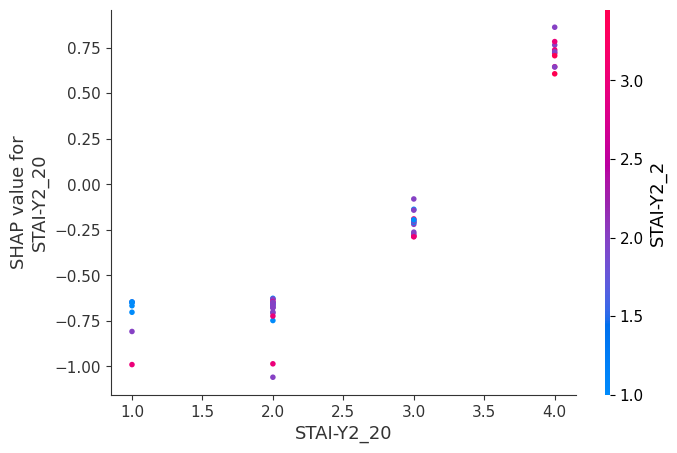


✅ Global SHAP Analysis complete!


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 15 — SHAP Global Analysis (Beeswarm + Bar + Dependence)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  SHAP GLOBAL ANALYSIS — HIGH RISK CLASS")
print("=" * 60)

X_shap      = X_test.copy()
X_shap_arr  = X_shap.values
feature_names = X_shap.columns.tolist()

explainer   = shap.TreeExplainer(xgb_monotone)
shap_values = explainer.shap_values(X_shap)   # shape: (n, features, 3)

HIGH_CLASS  = 2
sv_high     = shap_values[:, :, HIGH_CLASS]
assert sv_high.shape == X_shap_arr.shape, "Shape mismatch!"

# Beeswarm
print("\n📊 Beeswarm Plot — feature impact & direction")
shap.summary_plot(sv_high, X_shap_arr, feature_names=feature_names, show=True)

# Bar
print("\n📊 Feature Importance Bar Plot")
shap.summary_plot(sv_high, X_shap_arr, feature_names=feature_names,
                  plot_type="bar", show=True)

# Top-3 dependence plots
mean_abs_sv = np.abs(sv_high).mean(axis=0)
top3_idx    = np.argsort(mean_abs_sv)[-3:][::-1]
top3_names  = [feature_names[i] for i in top3_idx]
print(f"\n🔍 Top 3 influential features: {top3_names}")

for idx in top3_idx:
    print(f"\n📊 Dependence Plot → {feature_names[idx]}")
    shap.dependence_plot(idx, sv_high, X_shap_arr,
                         feature_names=feature_names, show=True)

print("\n✅ Global SHAP Analysis complete!")

  SHAP LOCAL ANALYSIS — SINGLE STUDENT
  Student index : 1
  True class    : High Risk
  Predicted     : High Risk

📊 Waterfall Plot


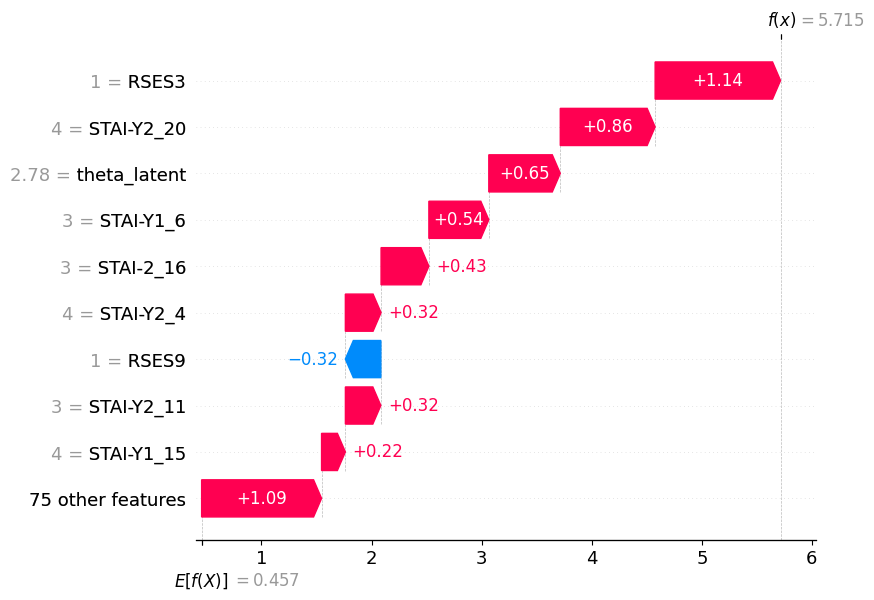


📊 Force Plot


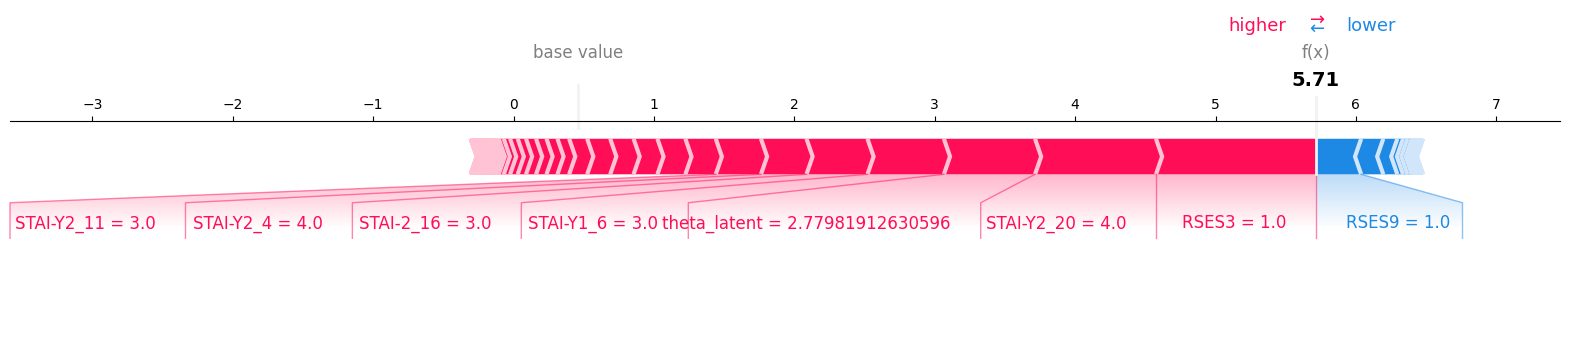


✅ Local SHAP Analysis complete!


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 — SHAP Local Analysis (Single High-Risk Student)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  SHAP LOCAL ANALYSIS — SINGLE STUDENT")
print("=" * 60)

# Pick a High Risk student for the most interesting explanation
high_risk_indices = np.where(y_test.values == HIGH_CLASS)[0]
sample_idx        = high_risk_indices[0] if len(high_risk_indices) > 0 else 0

single_sv   = sv_high[sample_idx]
single_data = X_shap.iloc[sample_idx]

print(f"  Student index : {sample_idx}")
print(f"  True class    : {PROFILE_NAMES[y_test.iloc[sample_idx]]}")
print(f"  Predicted     : {PROFILE_NAMES[xgb_monotone.predict(X_shap.iloc[[sample_idx]])[0]]}")

# Waterfall
print("\n📊 Waterfall Plot")
shap.waterfall_plot(shap.Explanation(
    values=single_sv,
    base_values=explainer.expected_value[HIGH_CLASS],
    data=single_data,
    feature_names=feature_names
))

# Force plot
print("\n📊 Force Plot")
shap.initjs()
shap.force_plot(
    explainer.expected_value[HIGH_CLASS],
    single_sv, single_data,
    matplotlib=True
)
plt.show()
print("\n✅ Local SHAP Analysis complete!")